# Decomposition - Leslie-Gower Population Dynamics Example

The following example is based on the dynamics of a general predator-prey system described by {cite}`bazykin1998` consisting of a set of ODEs.

$$
\begin{align}
\frac{dx_0}{dt} &= (r_1-a_1x_1-b_1x_0)x_0  \tag{1}\\
\frac{dx_1}{dt} &= (r_2 - a_2\frac{x_1}{x_0}) \tag{2}
\end{align}
$$

Here, $x_0(t)$ represents the evolution of the prey population, while $x_1(t)$ represents the predator. For this example, the constant parameters include: the intrinsic growth rate of prey and predator, $r_1=r_2=\frac{1}{5}$, the predation rate $a_1=\frac{1}{5}$, the intra-prey competition coefficient, $b_1=\frac{1}{10}$, and the predator food-scarcity (or Leslie Gower) coefficient, $a_2=\frac{1}{100}$.

We will assume that the predator population evolution rate, $r_2-a_2 \frac{x_1}{x_0}$, is unknown, and we would like to use a Neural Network to approximate the term. Written explicitly:

$$
\begin{align}
z(t) = r_2-a_2 \frac{x_1}{x_0} &= f_{NN}(x(t), \theta)  \tag{3} \\
\end{align}
$$

**NOTE:** This example uses the high-level `HybridDAE` wrapper, whose `.fit()` and `.predict()` methods orchestrate the full smoother, pretrain, train, and inference pipeline. To run each stage explicitly, call the stage functions directly as documented in the [API reference](../api/hybrid_dae.md).

<!-- Additionally, we will assume knowledge of the Lyapunov function given below in order to improve generalization by imposing mechanistic path constraints during model training. While Lyapunov functions are not typically known when true system dynamics are not known, adding this path constraint is intended to demonstrate SiNDAE's robustness to complex constraints.

$$
\begin{align}
V(t) =\ln \left( \frac{x_0}{x^*_0} \right) +\frac{x^*_0}{x_0} + \frac{a_1x^*_0}{x_2} \left( \ln \left( \frac{x_1}{x^*_1} \right) + \frac{x^*_1}{x_1} \right) \tag{4}
\end{align}
$$

where $x^*_0=\frac{r_1a_2}{a_1r_2+a_2b_1}$ and $x^*_1=\frac{r_1r_2}{a_1r_2+a_2b_1}$.

This becomes part of the DAE system in the form of an inequality path constraint given by:

$$
\begin{align}
\frac{dV}{dt} \le 0 \tag{5}
\end{align}
$$ -->

Let's start with the required imports

In [1]:
%matplotlib inline

import logging
import jax
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae.data_utils import InstanceData
from sindae import generate_data, HybridDAE
from sindae.algorithms.smoother import SmootherConfig
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.decomp.train import DecompConfig
from sindae.solvers import SolverConfig
from sindae.plot_utils import plot_instance_data, plot_training_history

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Defining a Problem

As in [Four Tank Example](four_tank_example.ipynb), the Leslie Gower system should be defined as a class, inheriting from `ProblemDefinition` and implementing `build_trajectory()`, `get_input_vars()`, and `get_ouput_vars()`. In this example problem, we know the true dynamics of our problem (i.e. the $r_2 - a_2\frac{x_1}{x_0}$ dynamics), so the `true_constraints()` can be defined, allowing synthetic data generation and prediction comparison to the ground truth.

In [2]:
class LeslieGowerProblem(ProblemDefinition):
    def __init__(
        self,
        ## Additional Args ##
        params,
        lyap_descent,
        ## ProblemDefinition Args ##
        ics, 
        input_dim, 
        z_dim, 
        t_span, 
        nfe, 
        ncp, 
        obs_times = None, 
        obs_values = None, 
        obs_dim = None, 
        aux_vars_dim = None
    ):

        super().__init__(ics, input_dim, z_dim, 
                         t_span, nfe, ncp, obs_times, 
                         obs_values, obs_dim, aux_vars_dim)
        
        self.params = params
        self.lyap_descent = lyap_descent


    def build_trajectory(self, block: pyo.Block, traj_idx: int) -> None:
        t0, _ = self.t_span
        p     = self.params
        x0_ic = self.ics[traj_idx]

        denom = p['a1'] * p['r2'] + p['a2'] * p['b1']
        x0_ss = p['r1'] * p['a2'] / denom
        x1_ss = p['r1'] * p['r2'] / denom

        block.t    = dae.ContinuousSet(bounds=self.t_span)
        block.x    = pyo.Var(block.t, range(self.input_dim), initialize=1.0, within=pyo.NonNegativeReals)
        block.z    = pyo.Var(block.t, range(self.z_dim), initialize=0.0)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        block.lyap_var = pyo.Var(block.t, initialize=1.0)
        block.dlyap_dt = dae.DerivativeVar(block.lyap_var, wrt=block.t)

        ## Differential Equations ##
        @block.Constraint(block.t, range(2))
        def diffeq(b, t, s):
            if s == 0:
                # Eqn (1)
                return b.dxdt[t, 0] == b.x[t, 0] * (p['r1'] - p['a1'] * b.x[t, 1] - p['b1'] * b.x[t, 0])
            else:
                # Eqn (2)
                return b.dxdt[t, 1] == b.x[t, 1] * b.z[t, 0] # z is the RHS of the equations to be learned by a NN


        ## Path Constraints (optional) ##
        @block.Constraint(block.t)
        def lyap_constr(b, t):
            # Eqn (4)
            return b.lyap_var[t] == (
                pyo.log(b.x[t, 0] / x0_ss) + x0_ss / b.x[t, 0]
                + (p['a1'] * x0_ss / p['a2'])
                * (pyo.log(b.x[t, 1] / x1_ss) + x1_ss / b.x[t, 1])
            )

        if self.lyap_descent:
            @block.Constraint(block.t)
            def lyap_descent_constr(b, t):
                if t == t0:
                    return pyo.Constraint.Skip
                # Eqn (5)
                return b.dlyap_dt[t] <= 0

        for j in range(2):
            block.x[t0, j].fix(float(x0_ic[j]))

    
    ## Ground Truth ##
    def add_true_output_constraints(self, block: pyo.Block) -> None:
        p = self.params

        @block.Constraint(block.t)
        def true_z(b, t):
            return b.z[t, 0] == p['r2'] - p['a2'] * b.x[t, 1] / b.x[t, 0]
        
        
    def get_input_vars(self, block, t):  
        return [block.x[t, j] for j in range(2)]
    
    def get_output_vars(self, block, t): 
        return [block.z[t, 0]]
    
    def get_aux_vars(self, block, t):    
        return [block.lyap_var[t]]

Defining the model's mechanistic parameters discussed above.

In [3]:
LG_PARAMS = {
    'a1': 0.2,      # a_1 = 1/5
    'a2': 0.01,     # a_2 = 1/100
    'r1': 0.2,      # r_1 = 1/5
    'r2': 0.2,      # r_1 = 1/5
    'b1': 0.1,      # b_1 = 1/10
}

SEED = 0

Next, define the initial conditions for the data generation from the ground truth (since this is a known example). In this example, we will train for only one trajectory and thus require only one $(x_0, x_1)$ state variable IC pair.

In [4]:
## Initial Conditions ##
LG_ICS = np.array([[1.0, 0.1]])     # traj_0: x_t0 = [x_0, x_1]

Next, define the observed variable state dimension, $x(t)$, the number of NN modeled variables, and $z(t)$. There are no algebraic variables, $y(t)$ in this problem.

In [5]:
## Problem dimensions ##
FT_STATE_DIM = 2     # NN input dim
FT_Z_DIM     = 1     # NN output dim


The timespan over which the model should be solved.

In [6]:
## Time span ##
T_SPAN = (0, 80)

Training discretization scheme. See [Four Tank Example](four_tank_example.ipynb) for more details.

In [7]:
## Discretization for data generation with true model ##
NFE_DATA  = 60
NCP_DATA  = 3

Now we can define the problem instance

In [8]:
## Define the problem instance ##
problem = LeslieGowerProblem(
    # Additional args
    params=LG_PARAMS,
    lyap_descent=False,
    # Probelem definition args
    ics=LG_ICS,
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_DATA, 
    ncp=NCP_DATA,
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=None
    )


## Generating the Data

With the problem defined, we can use the `generate_data()` function to generate the synthetic training data.

In [9]:
## Added noise standard deviation ##
NOISE_STD = np.array([0.05, 0.05])

## Ground truth observation frequency ##
OBS_EVERY = 4

In [10]:
print('=== 1. Generating data ===')
true_data: InstanceData = generate_data(
    problem=problem, 
    noise_std=NOISE_STD, 
    obs_every=OBS_EVERY, 
    seed=SEED,
)

=== 1. Generating data ===


generate_data: ok / optimal


## Step 1 - Defining the Neural Network

Before pretraining, the NN used to estimate the $z(t)$ terms should be defined. SinDAE, comes equipped with a `SimpleMLP` class as an equinox MLP implementation, which we will be using for this example. To set up your own NN architecture, see [Neural Network Utilities](../api/nn_utils.md).

In [11]:
## Define the NN ##
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[16, 16],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)

## Step 2 - Configure the Pipeline Stages

The `HybridDAE` wrapper runs the full pipeline: the smoother (a data-fitting NLP with $z(t)$ free), supervised pretraining, and the training solve. Here we select the **decomposition** method, which alternates Adam parameter updates with KKT-gradient back-solves through the DAE. The decomposition subproblems are solved with the chosen NLP solver (POUNCE by default), and their KKT systems with the linear solver (FERAL by default).

The training discretization can differ from the data-generation grid, so we update the problem's `nfe` / `ncp` before fitting.

In [12]:
## Training discretization (may differ from the data-generation grid) ##
NFE_TRAIN = 40
NCP_TRAIN = 3

problem.nfe = NFE_TRAIN
problem.ncp = NCP_TRAIN

## Smoother stage ##
SMOOTH_COEF = 1.0
smoother_config = SmootherConfig(smooth_coef=SMOOTH_COEF)

## Pretraining stage ##
pretrain_config = PretrainConfig(
    epochs=200,
    batch_size=32,
    reg_coef=1e-3,
)

## Decomposition training stage ##
decomp_cfg = DecompConfig(
    n_steps=300,
    lr=5e-3,
    init_slack_coef=1e1,
    param_reg_coef=1e-3,
)

## NLP solver options for the decomposition subproblem solves ##
solver_options = SolverConfig(
    tol=1e-6,
    max_iter=300,
)

## Step 3 - Fit the Hybrid Model (Decomposition)

Assemble the stage configs into a `HybridDAE` with `method="decomposition"` and call `fit`. The decomposition method has no single training termination (its per-step inner solves are recorded in `model.history` instead), which we plot below. Every intermediate stays reachable as an attribute (`model.smoother_data`, `model.trained_data`, `model.history`).

In [13]:
model = HybridDAE(
    method="decomposition",
    nlp_solver="pounce",
    linear_solver="feral",
    net=mlp,
    smoother=smoother_config,
    pretrain=pretrain_config,
    train=decomp_cfg,
    solver_options=solver_options,
    unfix_io=True,
)

print('=== Fitting hybrid model (decomposition) ===')
model.fit(problem, metrics=["rmse"])

## Intermediates stay reachable after fit ##
smoother_data = model.smoother_data
trained_data  = model.trained_data
history       = model.history

=== Building smoother for 1 trajectories (smooth_coef=1.0) ===


=== Fitting hybrid model (decomposition) ===


  Smoother: ok / optimal


=== Building decomp model for 1 trajectories (rank 0) ===


=== Training (300 steps) ===


...

  step  290  obj=9.7802e-03  data_fit=9.7800e-03  slack=1.90e-08  |grad|=3.96e-04  lr=5.00e-03  slack_coef=1.0e+01  step_s=0.10


  step  300  obj=9.6929e-03  data_fit=9.6897e-03  slack=3.18e-07  |grad|=1.66e-04  lr=5.00e-03  slack_coef=1.0e+01  step_s=0.10


=== Training complete ===


Identifier                                  ncalls   cumtime   percall      %
-----------------------------------------------------------------------------
training                                         1    30.660    30.660  100.0
        ---------------------------------------------------------------------
        step                                   300    30.648     0.102  100.0
             ----------------------------------------------------------------
             get_values                        300     0.125     0.000    0.4
             grad_eval                         300     1.543     0.005    5.0
                       ------------------------------------------------------
                       back_solve              300     0.040     0.000    2.6
                       del_obj_del_rho         300     0.053     0.000    3.5
                       kkt_matrix              300     0.523     0.002   33.9
                       numeric_fact            300     0.653    

=== Per Trajectory Metrics ===
RMSE: 
╒════════╤═══════════╤═══════════╕
│        │       x_0 │       x_1 │
╞════════╪═══════════╪═══════════╡
│ traj_0 │ 0.0471514 │ 0.0677107 │
╘════════╧═══════════╧═══════════╛


## Plot Results


<Figure size 1920x1440 with 0 Axes>

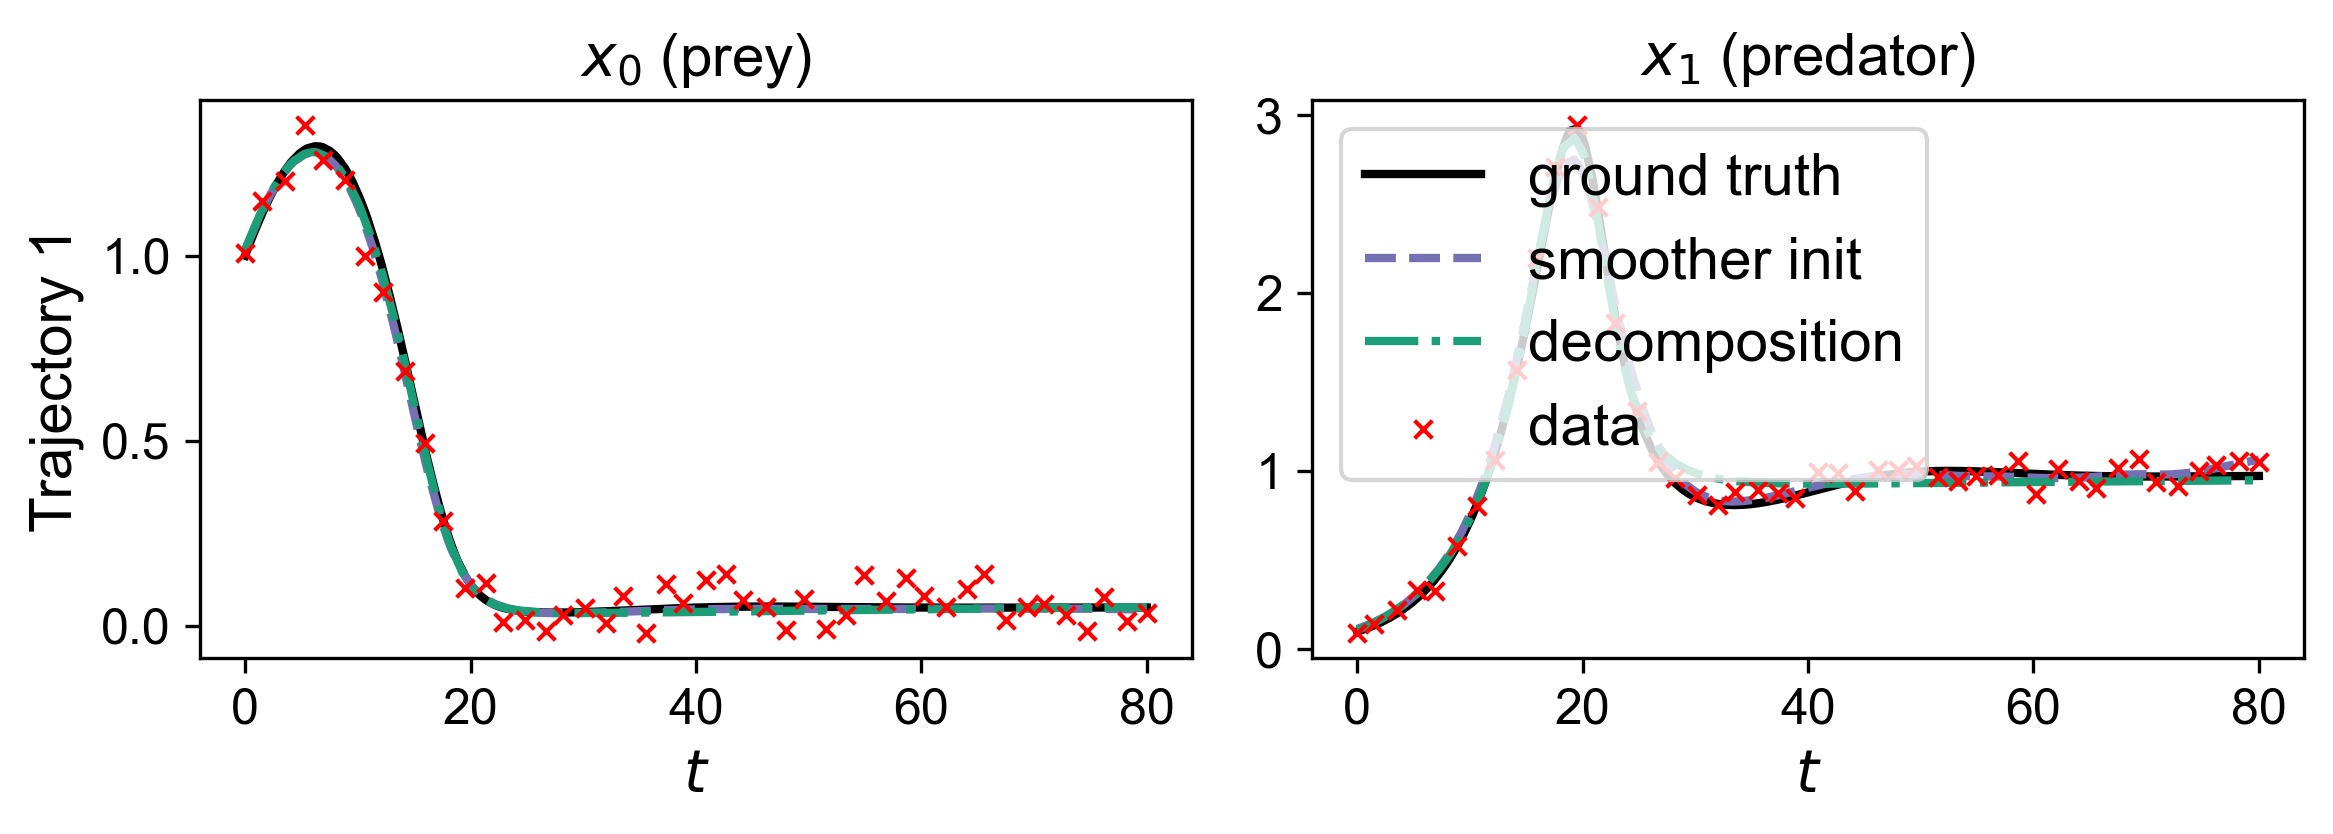

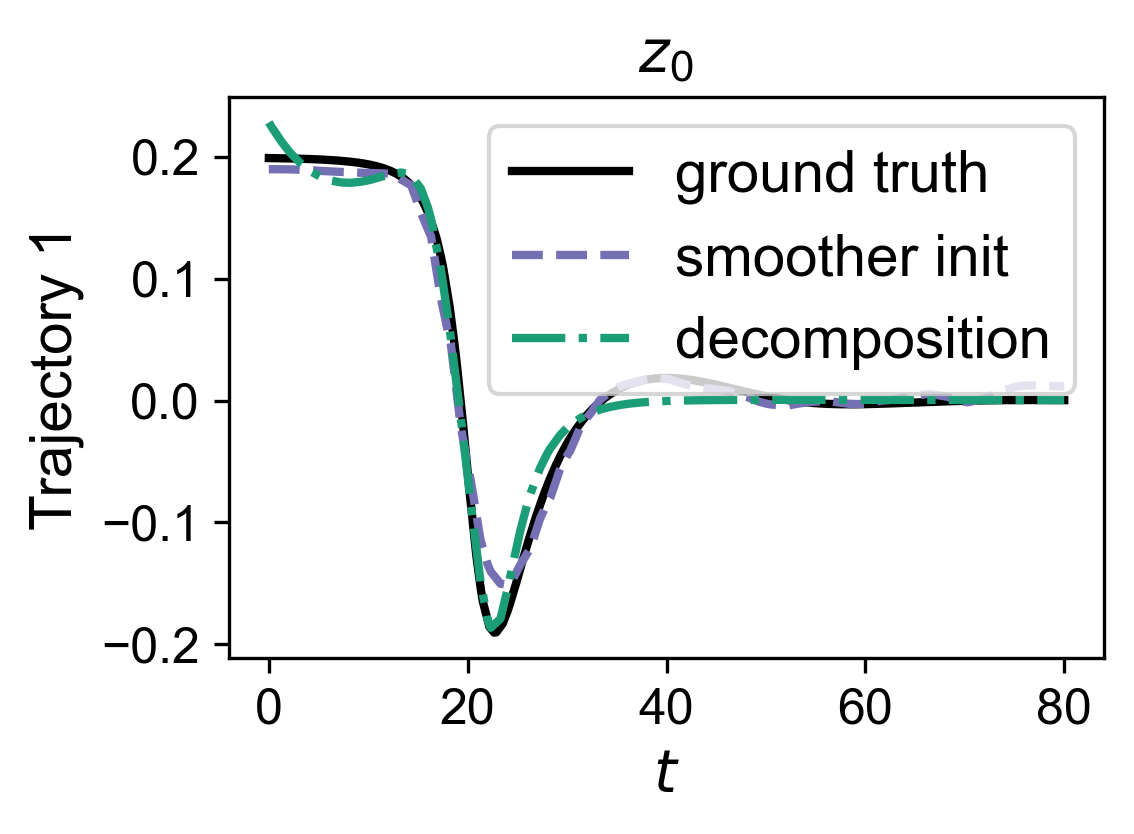

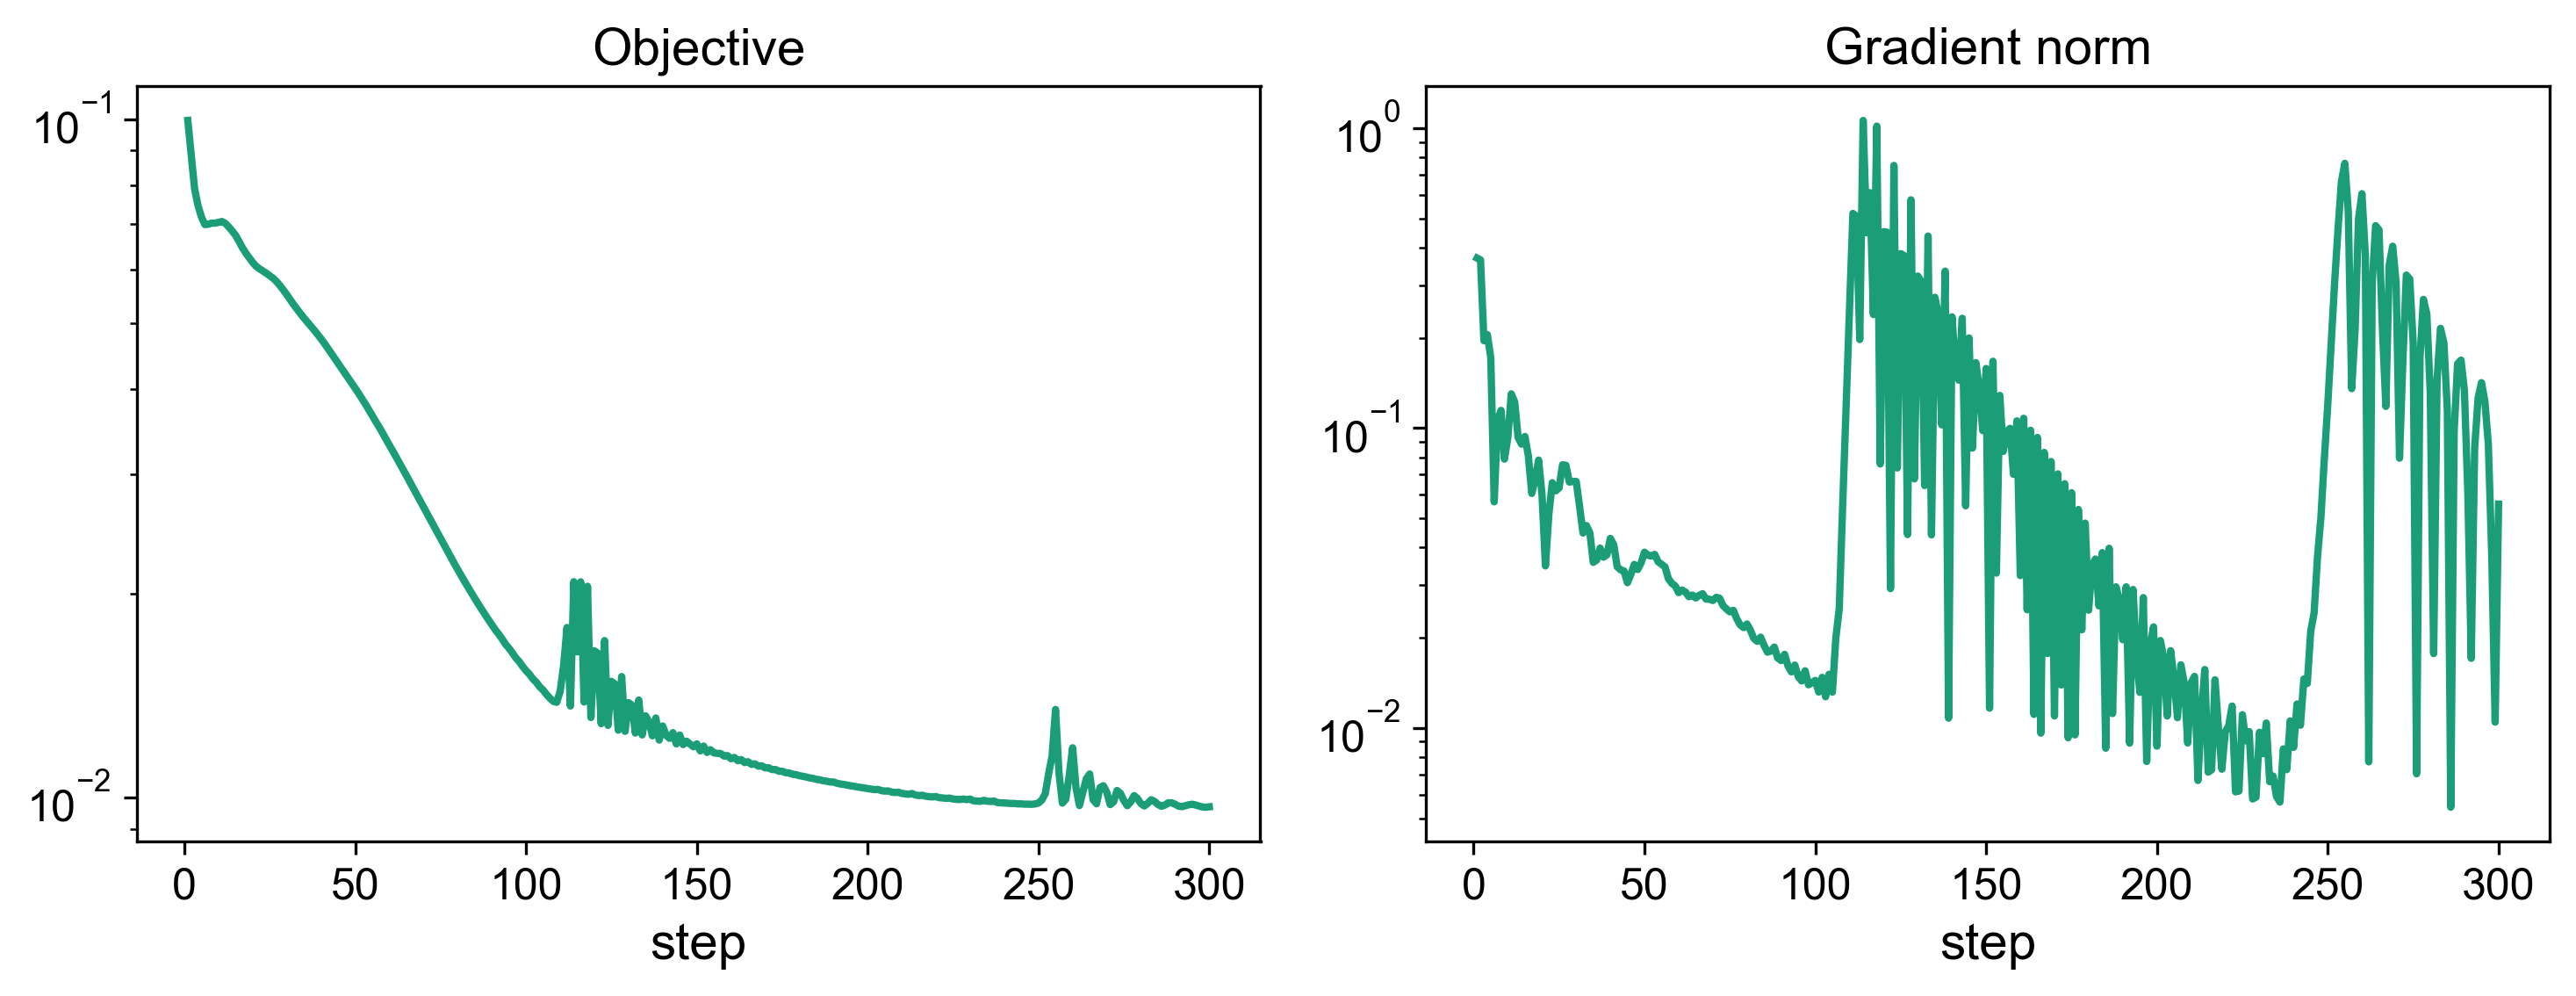

In [14]:
STATE_NAMES  = ['$x_0$ (prey)', '$x_1$ (predator)']
OUTPUT_NAMES = ['$z_0$']

datasets = [
    (true_data,     'ground truth',  {'color': 'black', 'ls': '-'}),
    (smoother_data, 'smoother init', {'color': 'C2',    'ls': '--'}),
    (trained_data,  'decomposition', {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

fig_h, _ = plot_training_history(history)

plt.show()

## Step 4 - Inference using Trained Model

Now that the hybrid model is trained, we can call `model.predict()` to predict trajectories given different initial conditions.

Accordingly, we can set new initial conditions for a new instance of the Leslie-Gower problem defined above. Other parameters including the number of discretization points, the number of collocation points, the time span, or the mechanistic parameters can also be altered before doing inference.

In [15]:
## Validation Trajectory ICs##
LG_VAL_ICS = np.array([[5.0, 0.3]])  

# can also edit the discretization for demonstration
NFE_VAL = 20 
NCP_VAL = 2

val_problem = LeslieGowerProblem(
    # Additional args
    params=LG_PARAMS,
    lyap_descent=False,
    # ProblemDefinition args
    ics=LG_VAL_ICS,         # Validation ICs
    input_dim=FT_STATE_DIM,
    z_dim=FT_Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_VAL,            # Validation
    ncp=NCP_VAL,            # Validation
    obs_dim=FT_STATE_DIM,
    aux_vars_dim=None
    )

Since we know the ground truth dynamics for this problem, we can generate a ground truth trajectory to compare the inference result to. Of course, when making predictions on real problems, this is not usually possible. Here, the ground truth curve in intended to serve as a visual reference for hybrid model predictive capacity once trained.

A ground truth curve can be generated using the `generate_data()` function with `noise_std` set to 0 (for each dependent variable).

In [16]:
## Ground truth for visualisation ##
val_truth = generate_data(
    problem=val_problem, 
    noise_std=np.zeros(2),  # No added noise = ground truth
    obs_every=1,            # Observations = ground truth sampling
    seed=SEED)

generate_data: ok / optimal


`model.predict()` embeds the trained network in the new problem and solves the inference NLP. It reuses the normalization statistics captured during `fit` (from the smoother stage), so the network is evaluated in the space it was trained in, and returns the predicted trajectories as an `InstanceData` object directly.

By default, `predict` enforces the NN equality as a hard constraint (`slack_coef=0.0`). If that leads to convergence difficulties, a small `slack_coef` adds l1 slack to loosen the constraint within reason. See [Inference](../api/inference.md) for more details.

In [17]:
## Predict the validation trajectory with the trained model ##
val_results = model.predict(val_problem, slack_coef=1e-5)

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===


=== Solving inference model ===


  Inference: ok / optimal


Plotting, similar to above.

<Figure size 1920x1440 with 0 Axes>

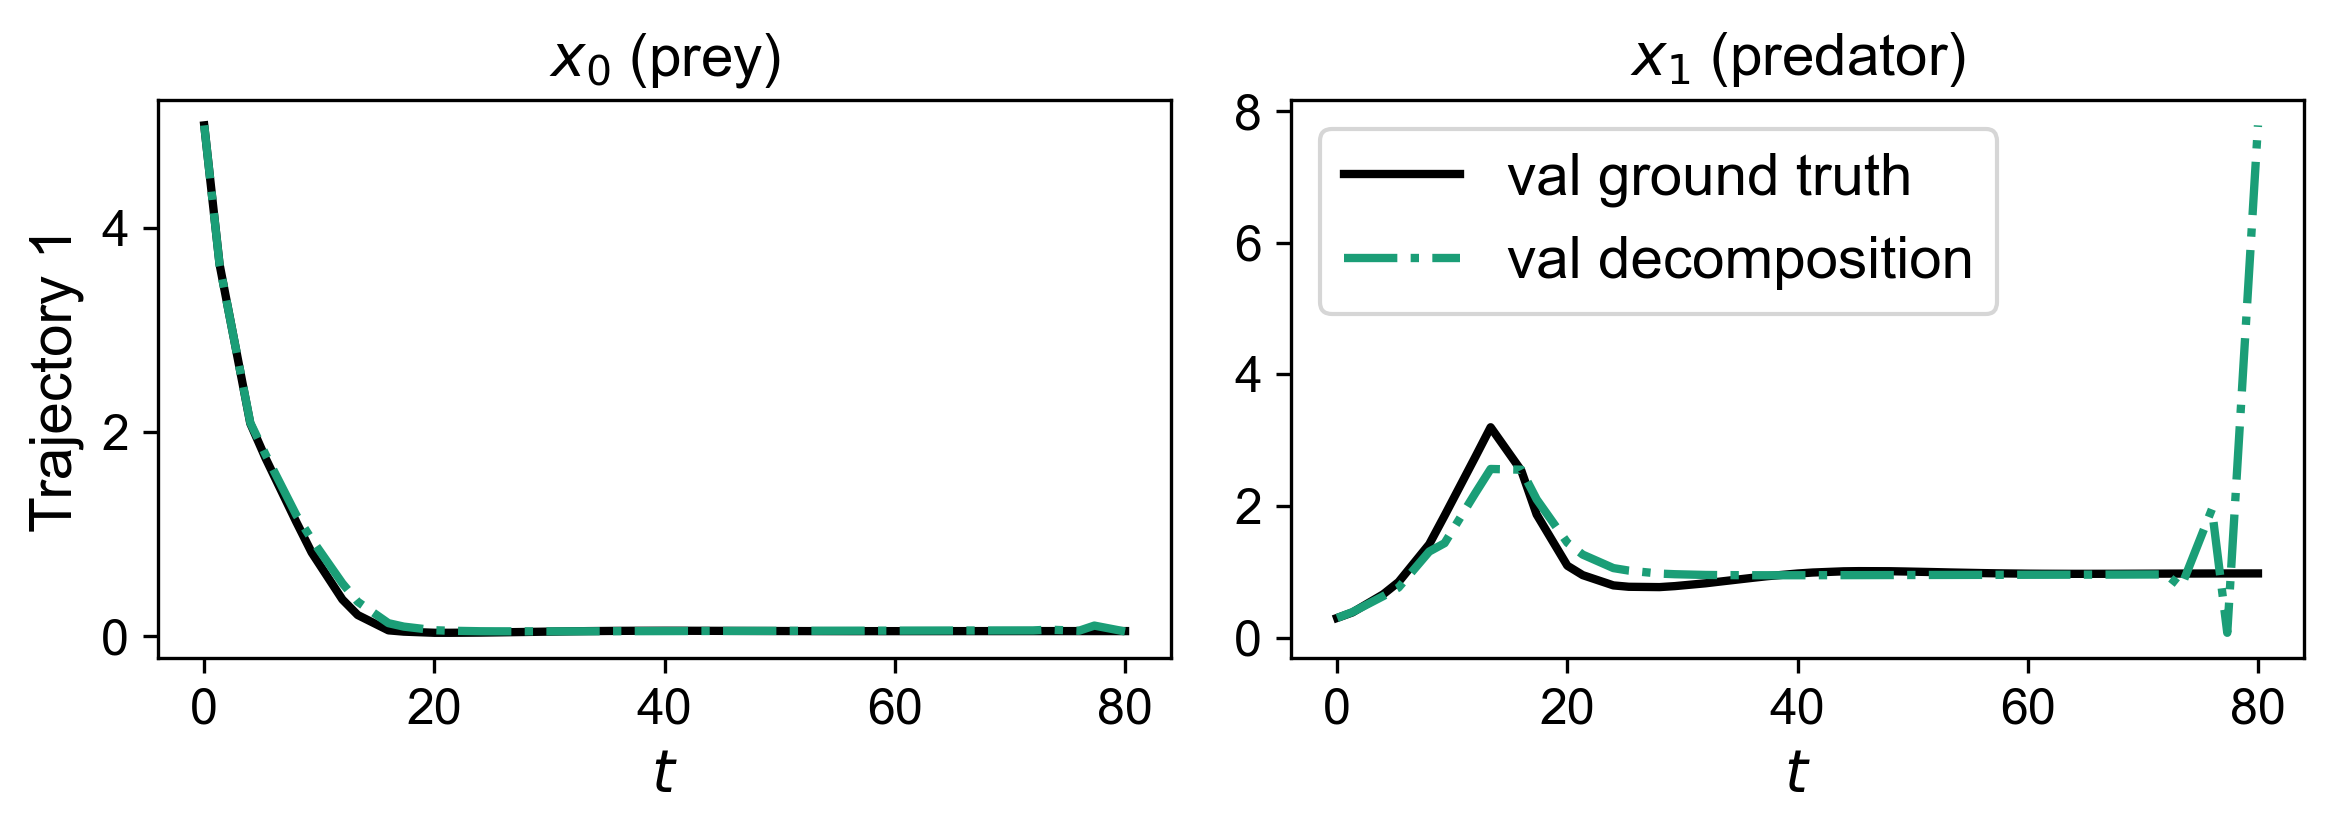

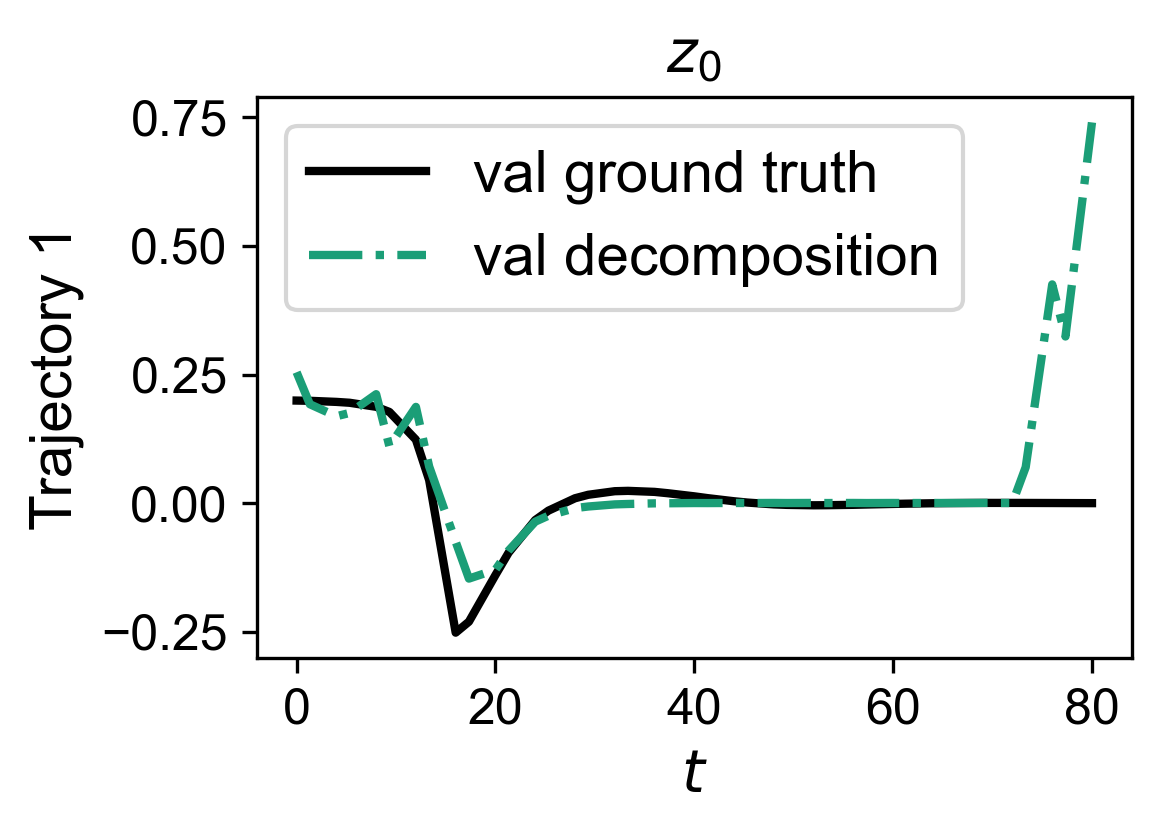

In [18]:
val_datasets = [
        (val_truth,     'val ground truth',  {'color': 'black', 'ls': '-'}),
        (val_results,   'val decomposition',  {'color': 'C0',    'ls': '-.'}),
    ]

plt.figure()
fig_x, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
fig_z, _ = plot_instance_data(
    datasets=val_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAMES,
    groups=['outputs'], legend_placement='last',
)

plt.show()

{cite}`lueg2025simultaneous`